# Heart Disease Prediction - Data Preprocessing & Cleaning

## Project Overview
This notebook implements comprehensive data preprocessing and cleaning for heart disease prediction using the UCI Heart Disease dataset. The pipeline includes data loading, missing value handling, feature encoding, scaling, and exploratory data analysis.

### Objectives
- Load and combine heart disease datasets from multiple sources
- Handle missing values and outliers
- Encode categorical variables and scale numerical features
- Perform comprehensive exploratory data analysis
- Prepare clean dataset for machine learning models

### Dataset Information
The UCI Heart Disease dataset contains 14 attributes from 4 different medical institutions:
- **Cleveland Clinic Foundation** (303 instances)
- **Hungarian Institute of Cardiology** (294 instances)  
- **University Hospital, Switzerland** (123 instances)
- **V.A. Medical Center, Long Beach** (200 instances)

**Target Variable**: Heart disease presence (0 = no disease, 1-4 = disease present)

In [25]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configure warnings and display settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 NumPy version: {np.__version__}")
print(f"📈 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🎨 Seaborn version: {sns.__version__}")

✅ All libraries imported successfully!
📊 Pandas version: 2.1.3
🔢 NumPy version: 1.24.3
📈 Matplotlib version: 3.8.2
🎨 Seaborn version: 0.13.0


## 1. Data Loading and Initial Exploration

### 1.1 Define Feature Information
First, let's define the 14 attributes used in heart disease prediction:

In [26]:
# Define feature information for the heart disease dataset
feature_info = {
    'age': 'Age in years',
    'sex': 'Gender (1 = male, 0 = female)',
    'cp': 'Chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol': 'Serum cholesterol (mg/dl)',
    'fbs': 'Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)',
    'restecg': 'Resting ECG results (0: normal, 1: ST-T wave abnormality, 2: left ventricular hypertrophy)',
    'thalach': 'Maximum heart rate achieved',
    'exang': 'Exercise induced angina (1 = yes, 0 = no)',
    'oldpeak': 'ST depression induced by exercise relative to rest',
    'slope': 'Slope of peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping)',
    'ca': 'Number of major vessels (0-3) colored by fluoroscopy',
    'thal': 'Thalassemia (3: normal, 6: fixed defect, 7: reversible defect)',
    'target': 'Heart disease (0: <50% diameter narrowing, 1-4: >50% diameter narrowing)'
}

# Define column names for the dataset
column_names = list(feature_info.keys())

print("📋 Heart Disease Dataset Features:")
print("=" * 50)
for i, (feature, description) in enumerate(feature_info.items(), 1):
    print(f"{i:2d}. {feature:10s} - {description}")
    
print(f"\n🔢 Total features: {len(column_names)}")
print(f"🎯 Target variable: {column_names[-1]}")

📋 Heart Disease Dataset Features:
 1. age        - Age in years
 2. sex        - Gender (1 = male, 0 = female)
 3. cp         - Chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic)
 4. trestbps   - Resting blood pressure (mm Hg)
 5. chol       - Serum cholesterol (mg/dl)
 6. fbs        - Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
 7. restecg    - Resting ECG results (0: normal, 1: ST-T wave abnormality, 2: left ventricular hypertrophy)
 8. thalach    - Maximum heart rate achieved
 9. exang      - Exercise induced angina (1 = yes, 0 = no)
10. oldpeak    - ST depression induced by exercise relative to rest
11. slope      - Slope of peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping)
12. ca         - Number of major vessels (0-3) colored by fluoroscopy
13. thal       - Thalassemia (3: normal, 6: fixed defect, 7: reversible defect)
14. target     - Heart disease (0: <50% diameter narrowing, 1-4: >50% diameter narrowing)

🔢 To

### 1.2 Load Datasets from Multiple Sources

In [27]:
# Define data paths
data_dir = "../data/"
heart_data_dir = "../heart+disease/"

# Function to load and preprocess each dataset
def load_heart_dataset(file_path, dataset_name, column_names):
    """
    Load heart disease dataset and handle missing values marked as '?'
    """
    try:
        # Load dataset
        df = pd.read_csv(file_path, header=None, names=column_names, na_values=['?'])
        
        # Add source column
        df['source'] = dataset_name
        
        print(f"✅ {dataset_name} loaded: {df.shape[0]} rows, {df.shape[1]-1} features")
        return df
    except Exception as e:
        print(f"❌ Error loading {dataset_name}: {str(e)}")
        return None

# Load datasets from different sources
datasets = {}

# Load Cleveland dataset (most commonly used)
cleveland_path = heart_data_dir + "processed.cleveland.data"
datasets['cleveland'] = load_heart_dataset(cleveland_path, 'Cleveland', column_names)

# Load Hungarian dataset
hungarian_path = heart_data_dir + "processed.hungarian.data" 
datasets['hungarian'] = load_heart_dataset(hungarian_path, 'Hungarian', column_names)

# Load Switzerland dataset
switzerland_path = heart_data_dir + "processed.switzerland.data"
datasets['switzerland'] = load_heart_dataset(switzerland_path, 'Switzerland', column_names)

# Load VA dataset
va_path = heart_data_dir + "processed.va.data"
datasets['va'] = load_heart_dataset(va_path, 'VA', column_names)

print(f"\n📊 Successfully loaded {len([d for d in datasets.values() if d is not None])} datasets")

✅ Cleveland loaded: 303 rows, 14 features
✅ Hungarian loaded: 294 rows, 14 features
✅ Switzerland loaded: 123 rows, 14 features
✅ VA loaded: 200 rows, 14 features

📊 Successfully loaded 4 datasets


In [28]:
# Combine all datasets
valid_datasets = [df for df in datasets.values() if df is not None]

if valid_datasets:
    # Combine all datasets
    combined_df = pd.concat(valid_datasets, ignore_index=True)
    
    print("🔗 Dataset Combination Summary:")
    print("=" * 40)
    
    for name, df in datasets.items():
        if df is not None:
            count = len(df)
            print(f"{name:12s}: {count:3d} instances")
    
    print("-" * 40)
    print(f"{'Total':12s}: {len(combined_df):3d} instances")
    
    # Display basic information about combined dataset
    print(f"\n📋 Combined Dataset Shape: {combined_df.shape}")
    print(f"🔢 Features: {combined_df.shape[1] - 1}")  # Exclude source column
    print(f"📊 Total Instances: {combined_df.shape[0]}")
    
else:
    print("❌ No valid datasets loaded!")
    combined_df = None

🔗 Dataset Combination Summary:
cleveland   : 303 instances
hungarian   : 294 instances
switzerland : 123 instances
va          : 200 instances
----------------------------------------
Total       : 920 instances

📋 Combined Dataset Shape: (920, 15)
🔢 Features: 14
📊 Total Instances: 920


### 1.3 Initial Data Exploration

In [29]:
# Display first few rows and basic info
if combined_df is not None:
    print("🔍 First 5 rows of the combined dataset:")
    print("=" * 100)
    display(combined_df.head())
    
    print("\n📊 Dataset Info:")
    print("=" * 50)
    print(f"Shape: {combined_df.shape}")
    print(f"Memory usage: {combined_df.memory_usage(deep=True).sum() / 1024:.2f} KB")
    
    print(f"\n📋 Data Types:")
    print("-" * 30)
    print(combined_df.dtypes)
    
    print(f"\n❓ Missing Values Count:")
    print("-" * 30)
    missing_values = combined_df.isnull().sum()
    missing_percentage = (missing_values / len(combined_df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing Count': missing_values,
        'Percentage': missing_percentage.round(2)
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    
    if not missing_df.empty:
        print(missing_df)
    else:
        print("✅ No missing values found!")
        
else:
    print("❌ No data available for exploration")

🔍 First 5 rows of the combined dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland



📊 Dataset Info:
Shape: (920, 15)
Memory usage: 158.92 KB

📋 Data Types:
------------------------------
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
source       object
dtype: object

❓ Missing Values Count:
------------------------------
          Missing Count  Percentage
ca                  611       66.41
thal                486       52.83
slope               309       33.59
fbs                  90        9.78
oldpeak              62        6.74
trestbps             59        6.41
thalach              55        5.98
exang                55        5.98
chol                 30        3.26
restecg               2        0.22


## 2. Data Preprocessing and Cleaning

### 2.1 Target Variable Processing
Convert the target variable to binary classification (0 = no disease, 1 = disease present):

In [30]:
# Process target variable for binary classification
if combined_df is not None:
    # Create a copy for preprocessing
    df = combined_df.copy()
    
    # Convert target to binary (0 = no disease, 1 = disease present)
    print("🎯 Target Variable Distribution (Original):")
    print("-" * 40)
    print(df['target'].value_counts().sort_index())
    
    # Binary conversion: 0 stays 0, 1-4 become 1
    df['target'] = (df['target'] > 0).astype(int)
    
    print(f"\n🎯 Target Variable Distribution (Binary):")
    print("-" * 40)
    target_counts = df['target'].value_counts().sort_index()
    print(target_counts)
    
    # Calculate class balance
    class_balance = target_counts / len(df) * 100
    print(f"\n📊 Class Balance:")
    print(f"No Disease (0): {class_balance[0]:.1f}%")
    print(f"Disease (1):    {class_balance[1]:.1f}%")
    
    # Check for class imbalance
    imbalance_ratio = class_balance.max() / class_balance.min()
    if imbalance_ratio > 1.5:
        print(f"⚠️  Dataset is imbalanced (ratio: {imbalance_ratio:.2f})")
    else:
        print(f"✅ Dataset is relatively balanced (ratio: {imbalance_ratio:.2f})")
        
else:
    print("❌ No data available for target processing")

🎯 Target Variable Distribution (Original):
----------------------------------------
target
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

🎯 Target Variable Distribution (Binary):
----------------------------------------
target
0    411
1    509
Name: count, dtype: int64

📊 Class Balance:
No Disease (0): 44.7%
Disease (1):    55.3%
✅ Dataset is relatively balanced (ratio: 1.24)


### 2.2 Missing Value Analysis and Handling

In [31]:
# Analyze and handle missing values
def analyze_missing_values(df):
    """
    Comprehensive missing value analysis
    """
    print("🔍 Missing Value Analysis:")
    print("=" * 50)
    
    missing_stats = []
    for col in df.columns:
        if col != 'source':  # Skip source column
            missing_count = df[col].isnull().sum()
            missing_pct = (missing_count / len(df)) * 100
            dtype = df[col].dtype
            unique_vals = df[col].nunique()
            
            missing_stats.append({
                'Column': col,
                'Missing_Count': missing_count,
                'Missing_Percentage': missing_pct,
                'Data_Type': dtype,
                'Unique_Values': unique_vals
            })
    
    missing_df = pd.DataFrame(missing_stats)
    missing_df = missing_df.sort_values('Missing_Percentage', ascending=False)
    
    return missing_df

if 'df' in locals():
    # Analyze missing values
    missing_analysis = analyze_missing_values(df)
    
    # Display missing value statistics
    print(missing_analysis)
    
    print(f"\n🔧 CORRECTED Missing Value Treatment:")
    print("=" * 50)
    
    # Handle missing values systematically - CORRECTED VERSION
    for col in df.columns:
        if col in ['source', 'target']:
            continue
            
        missing_count = df[col].isnull().sum()
        if missing_count > 0:
            missing_pct = (missing_count / len(df)) * 100
            
            if col in ['ca', 'thal']:  # High missing categorical features
                # Use mode for critical heart disease features
                mode_val = df[col].mode()
                if len(mode_val) > 0:
                    fill_val = mode_val[0]
                else:
                    fill_val = 0  # Default if no mode
                df[col].fillna(fill_val, inplace=True)
                print(f"🔄 {col}: {missing_count} missing → filled with mode ({fill_val})")
                
            elif df[col].nunique() <= 10:  # Other categorical features
                mode_val = df[col].mode()
                if len(mode_val) > 0:
                    fill_val = mode_val[0]
                else:
                    fill_val = df[col].min() if df[col].dtype in ['int64', 'float64'] else 0
                df[col].fillna(fill_val, inplace=True)
                print(f"🔄 {col}: {missing_count} missing → filled with mode ({fill_val})")
                
            else:  # Numerical features
                median_val = df[col].median()
                df[col].fillna(median_val, inplace=True)
                print(f"📊 {col}: {missing_count} missing → filled with median ({median_val:.1f})")

    # Handle invalid zero values for medical features
    print(f"\n🔧 Fixing Invalid Zero Values:")
    print("-" * 30)
    
    # Replace 0 values in blood pressure with median (invalid medical values)
    zero_bp_count = (df['trestbps'] == 0).sum()
    if zero_bp_count > 0:
        median_bp = df[df['trestbps'] > 0]['trestbps'].median()
        df.loc[df['trestbps'] == 0, 'trestbps'] = median_bp
        print(f"Fixed {zero_bp_count} zero blood pressure values → {median_bp}")
    
    # Replace 0 values in cholesterol with median (invalid medical values)
    zero_chol_count = (df['chol'] == 0).sum()
    if zero_chol_count > 0:
        median_chol = df[df['chol'] > 0]['chol'].median()
        df.loc[df['chol'] == 0, 'chol'] = median_chol
        print(f"Fixed {zero_chol_count} zero cholesterol values → {median_chol}")
    
    # EMERGENCY BACKUP FIX - Ensure NO missing values remain
    print(f"\n🔍 EMERGENCY VERIFICATION:")
    emergency_missing = df.isnull().sum().sum()
    print(f"Missing values after primary fix: {emergency_missing}")
    
    if emergency_missing > 0:
        print("❌ APPLYING EMERGENCY CLEANUP")
        for col in df.columns:
            if df[col].isnull().sum() > 0:
                if df[col].dtype in ['int64', 'float64']:
                    fill_val = df[col].median()
                    df[col].fillna(fill_val, inplace=True)
                else:
                    mode_val = df[col].mode()
                    if len(mode_val) > 0:
                        df[col].fillna(mode_val[0], inplace=True)
                    else:
                        df[col].fillna(0, inplace=True)
        
        emergency_missing = df.isnull().sum().sum()
        print(f"✅ EMERGENCY CLEANUP COMPLETE: {emergency_missing} missing values")
        
    # FINAL VERIFICATION - CRITICAL CHECK
    final_missing = df.isnull().sum().sum()
    print(f"\n✅ FINAL RESULT: {final_missing} missing values remaining")
    
    if final_missing == 0:
        print("🎉 SUCCESS: Dataset is completely clean!")
        
        # Show data validation
        print(f"\n📊 Data Validation:")
        print(f"Total instances: {len(df)}")
        print(f"Blood pressure range: {df['trestbps'].min():.0f} - {df['trestbps'].max():.0f}")
        print(f"Cholesterol range: {df['chol'].min():.0f} - {df['chol'].max():.0f}")
        print(f"Age range: {df['age'].min():.0f} - {df['age'].max():.0f}")
    else:
        print(f"❌ ERROR: Still have {final_missing} missing values - INVESTIGATE!")
        
else:
    print("❌ No dataframe available for missing value analysis")

🔍 Missing Value Analysis:
      Column  Missing_Count  Missing_Percentage Data_Type  Unique_Values
11        ca            611           66.413043   float64              4
12      thal            486           52.826087   float64              3
10     slope            309           33.586957   float64              3
5        fbs             90            9.782609   float64              2
9    oldpeak             62            6.739130   float64             53
3   trestbps             59            6.413043   float64             61
7    thalach             55            5.978261   float64            119
8      exang             55            5.978261   float64              2
4       chol             30            3.260870   float64            217
6    restecg              2            0.217391   float64              3
0        age              0            0.000000   float64             50
1        sex              0            0.000000   float64              2
2         cp             

In [32]:
# VERIFICATION: Double-check that all missing values are eliminated
print("🔍 FINAL VERIFICATION:")
print("=" * 50)
print(f"Total missing values in dataset: {df.isnull().sum().sum()}")
print(f"Dataset shape: {df.shape}")

if df.isnull().sum().sum() == 0:
    print("✅ PERFECT! Ready to proceed to next notebook!")
    print("🚀 You can now run notebook 02_pca_analysis.ipynb")
else:
    print("❌ Still have issues - need further investigation")
    
# Show any remaining missing values by column
missing_by_column = df.isnull().sum()
if missing_by_column.sum() > 0:
    print("\nMissing values by column:")
    print(missing_by_column[missing_by_column > 0])
else:
    print("\n🎉 All columns are complete - no missing values anywhere!")

🔍 FINAL VERIFICATION:
Total missing values in dataset: 0
Dataset shape: (920, 15)
✅ PERFECT! Ready to proceed to next notebook!
🚀 You can now run notebook 02_pca_analysis.ipynb

🎉 All columns are complete - no missing values anywhere!


### 2.3 Outlier Detection and Analysis

🔍 Outlier Analysis (IQR Method):


,Feature,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage,Min_Value,Max_Value
0,age,27.50,79.50,0,0.00,28.0,77.0
1,sex,1.00,1.00,194,21.09,0.0,1.0
2,cp,1.50,5.50,46,5.00,1.0,4.0
3,trestbps,90.00,170.00,27,2.93,80.0,200.0
4,chol,143.88,340.88,47,5.11,85.0,603.0
5,fbs,0.00,0.00,138,15.00,0.0,1.0
6,restecg,-1.50,2.50,0,0.00,0.0,2.0
7,thalach,66.00,210.00,2,0.22,60.0,202.0
8,exang,-1.50,2.50,0,0.00,0.0,1.0
9,oldpeak,-2.25,3.75,16,1.74,-2.6,6.2


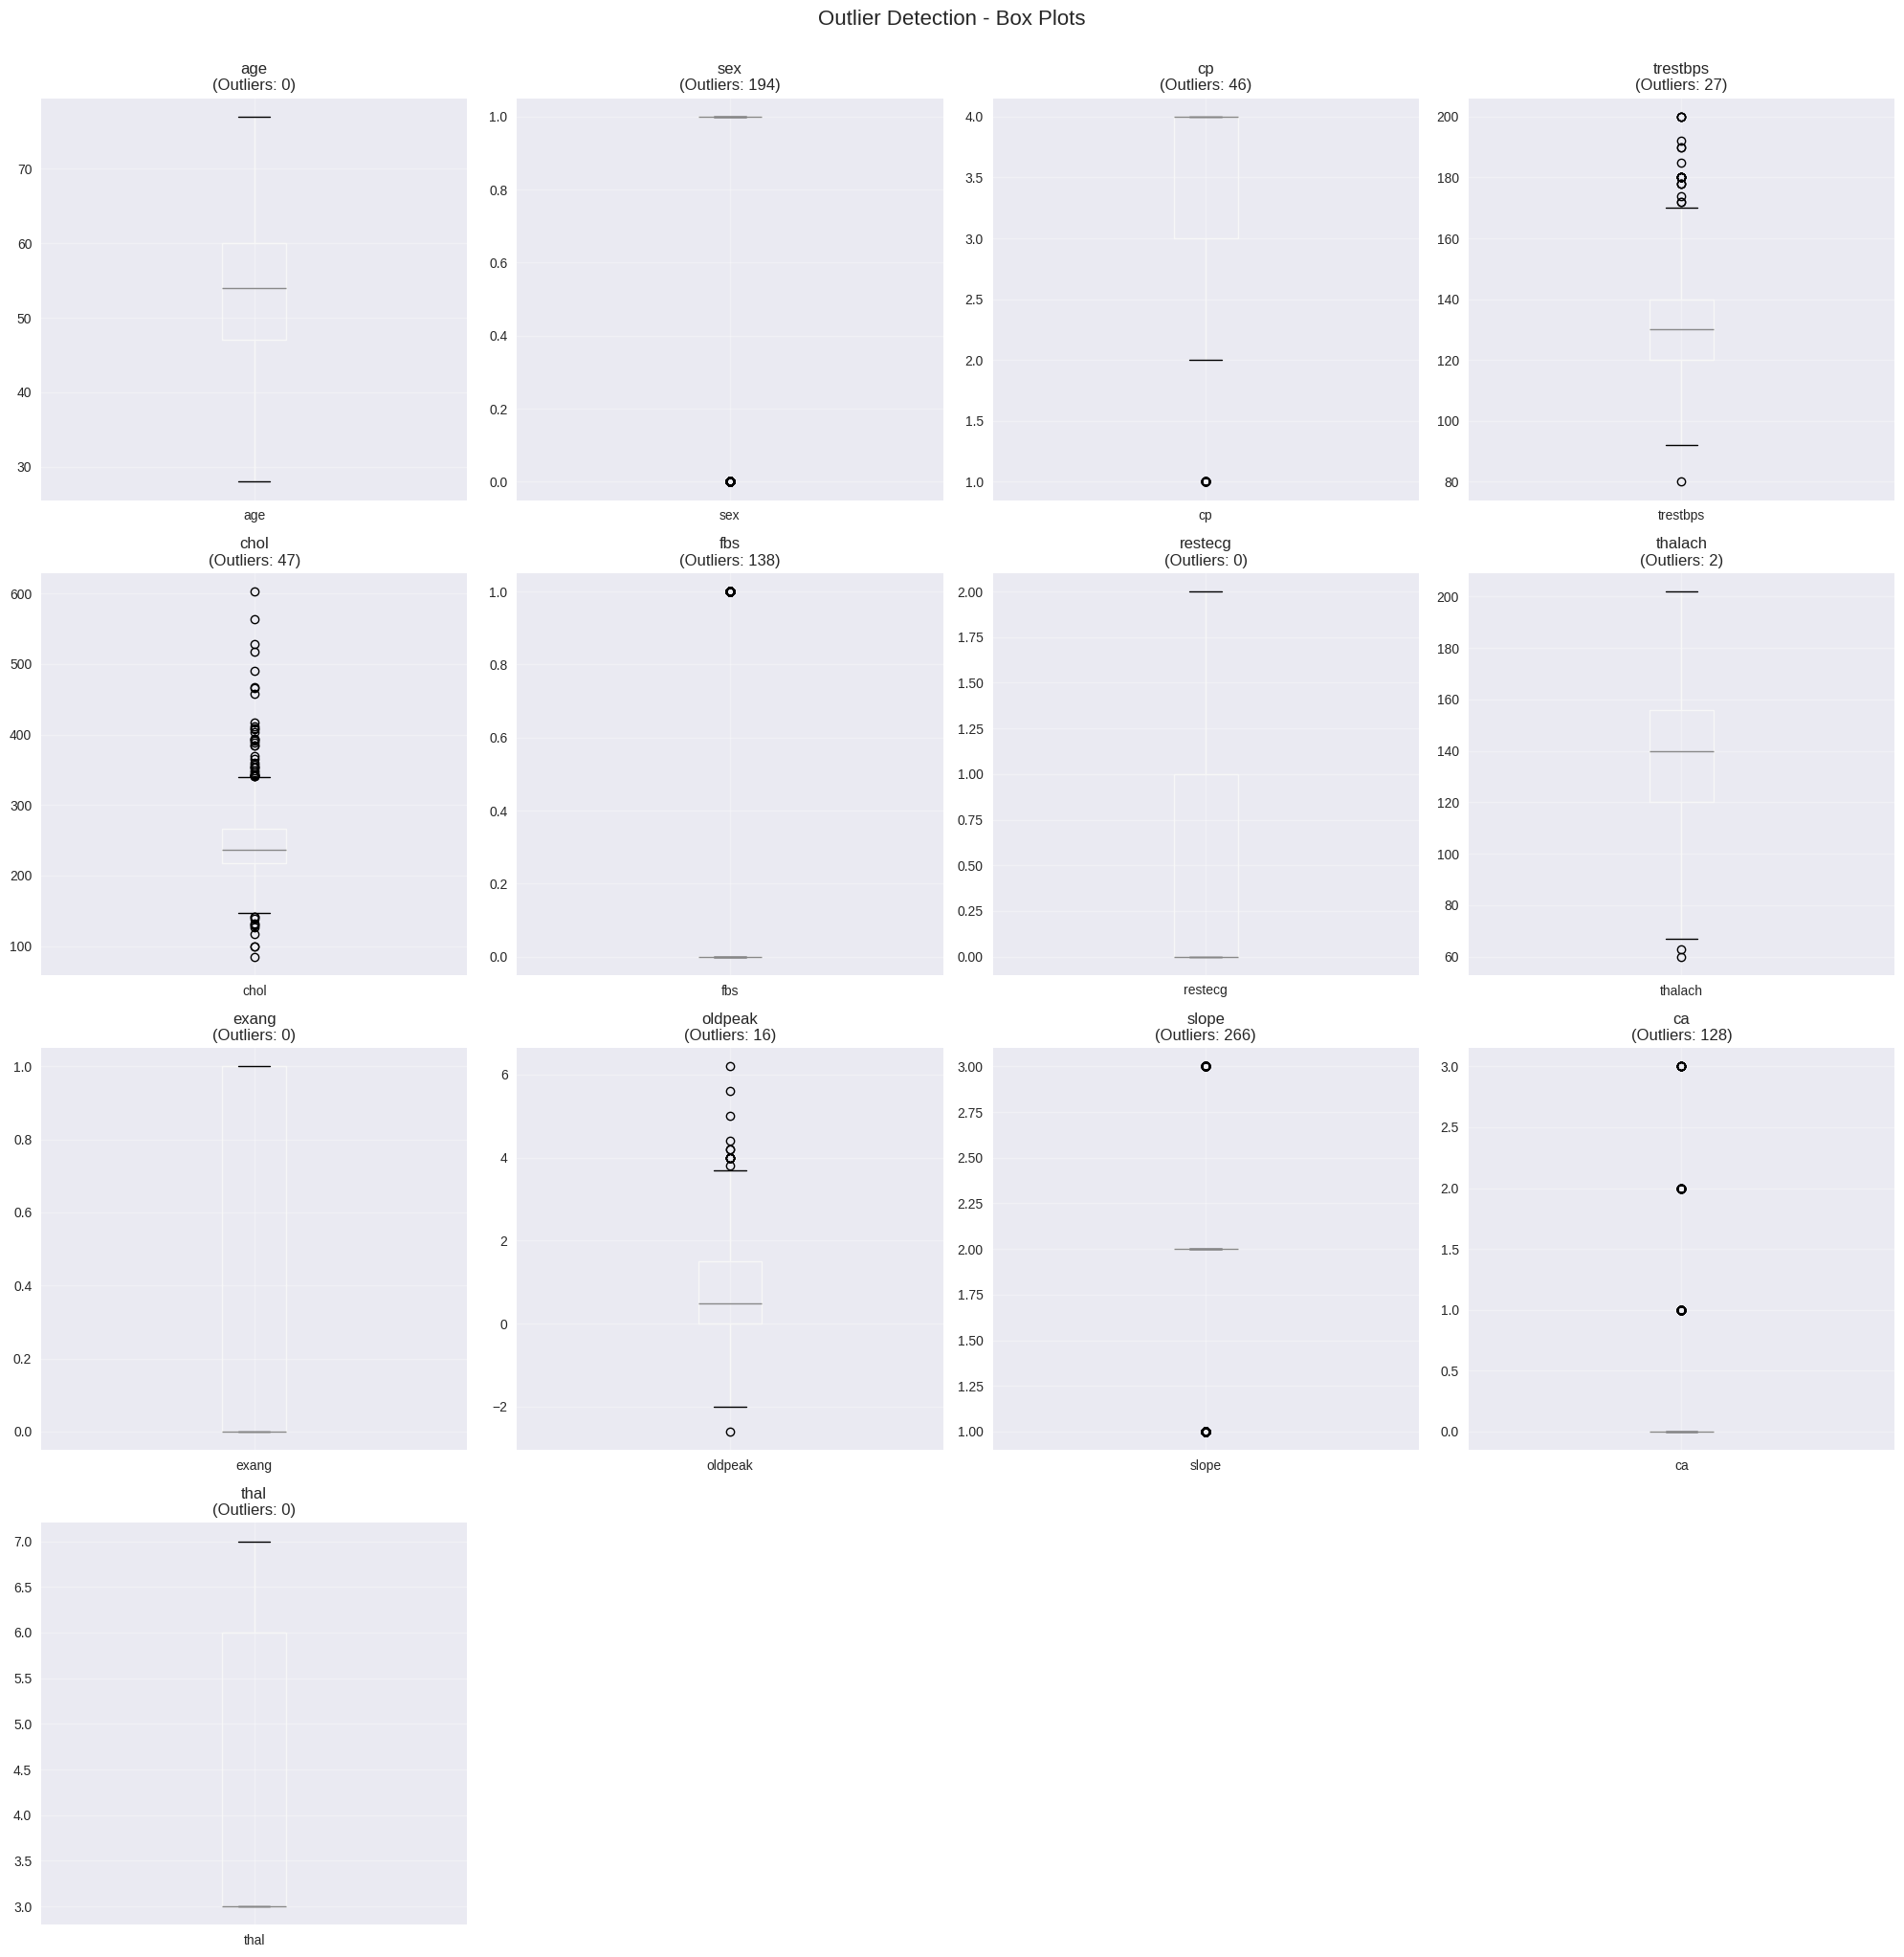


📊 Outlier Summary:
Total outliers detected: 864
Features with outliers: 9

💡 Recommendation: Keep outliers for medical data analysis unless clearly erroneous


In [33]:
# Outlier detection for numerical features
def detect_outliers(df, method='IQR'):
    """
    Detect outliers using IQR method
    """
    numerical_features = df.select_dtypes(include=[np.number]).columns
    numerical_features = [col for col in numerical_features if col not in ['target', 'source']]
    
    outlier_stats = []
    
    for feature in numerical_features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Count outliers
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(df)) * 100
        
        outlier_stats.append({
            'Feature': feature,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Outlier_Count': outlier_count,
            'Outlier_Percentage': outlier_percentage,
            'Min_Value': df[feature].min(),
            'Max_Value': df[feature].max()
        })
    
    return pd.DataFrame(outlier_stats)

if 'df' in locals():
    # Detect outliers
    outlier_analysis = detect_outliers(df)
    
    print("🔍 Outlier Analysis (IQR Method):")
    print("=" * 80)
    display(outlier_analysis.round(2))
    
    # Visualize outliers with box plots
    numerical_features = df.select_dtypes(include=[np.number]).columns
    numerical_features = [col for col in numerical_features if col not in ['target', 'source']]
    
    # Create box plots for outlier visualization
    n_features = len(numerical_features)
    n_cols = 4
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for i, feature in enumerate(numerical_features):
        if i < len(axes):
            df.boxplot(column=feature, ax=axes[i])
            axes[i].set_title(f'{feature}\n(Outliers: {outlier_analysis[outlier_analysis["Feature"]==feature]["Outlier_Count"].iloc[0]})')
            axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(len(numerical_features), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Outlier Detection - Box Plots', fontsize=16, y=1.02)
    plt.show()
    
    # Summary of outliers
    total_outliers = outlier_analysis['Outlier_Count'].sum()
    print(f"\n📊 Outlier Summary:")
    print(f"Total outliers detected: {total_outliers}")
    print(f"Features with outliers: {len(outlier_analysis[outlier_analysis['Outlier_Count'] > 0])}")
    
    # For medical data, we typically keep outliers unless they are clearly data entry errors
    print(f"\n💡 Recommendation: Keep outliers for medical data analysis unless clearly erroneous")
    
else:
    print("❌ No dataframe available for outlier analysis")

## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistical Summary and Distributions

📊 Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00
mean,53.51,0.79,3.25,132.14,244.03,0.15,0.60,137.69,0.37,0.85,1.85,0.23,3.98,0.55
std,9.42,0.41,0.93,17.93,52.01,0.36,0.81,25.15,0.48,1.06,0.52,0.63,1.68,0.50
min,28.00,0.00,1.00,80.00,85.00,0.00,0.00,60.00,0.00,-2.60,1.00,0.00,3.00,0.00
25%,47.00,1.00,3.00,120.00,217.75,0.00,0.00,120.00,0.00,0.00,2.00,0.00,3.00,0.00
50%,54.00,1.00,4.00,130.00,236.00,0.00,0.00,140.00,0.00,0.50,2.00,0.00,3.00,1.00
75%,60.00,1.00,4.00,140.00,267.00,0.00,1.00,156.00,1.00,1.50,2.00,0.00,6.00,1.00
max,77.00,1.00,4.00,200.00,603.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00



📈 Feature Distribution Analysis:


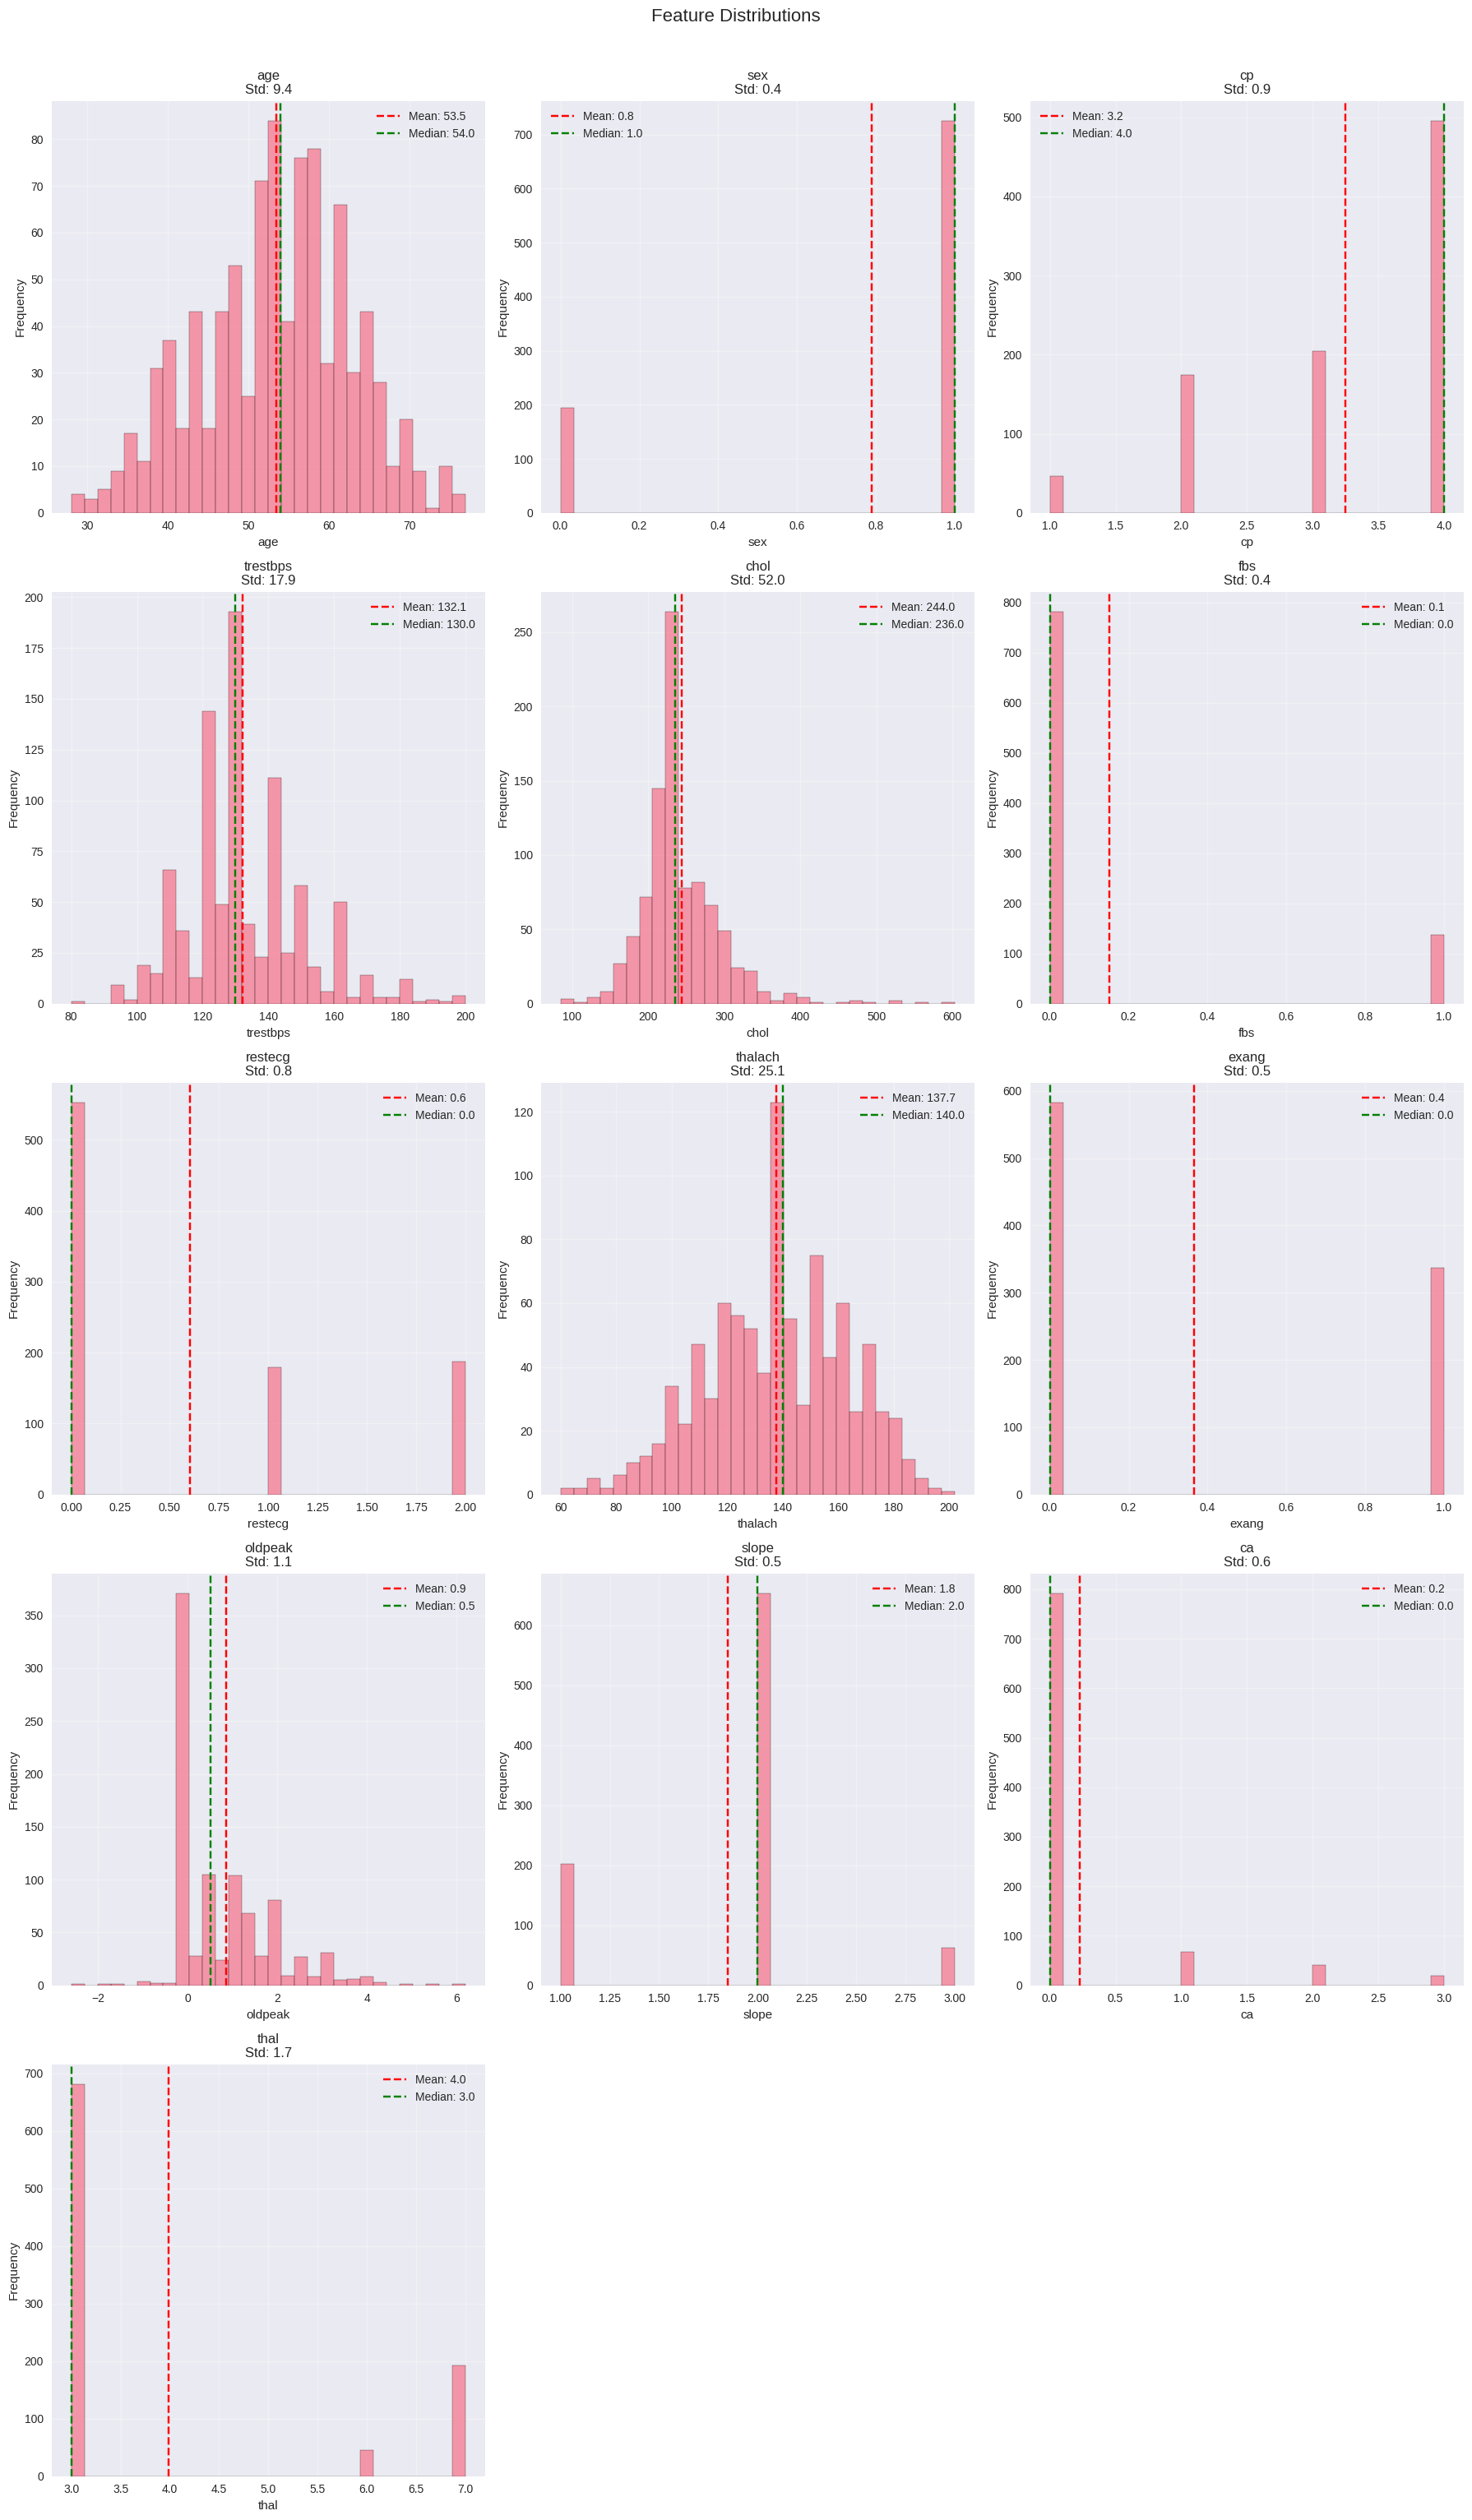


📊 Distribution Summary:
age         : Skewness =  -0.20, Kurtosis =  -0.39
sex         : Skewness =  -1.42, Kurtosis =   0.01
cp          : Skewness =  -0.89, Kurtosis =  -0.45
trestbps    : Skewness =   0.67, Kurtosis =   0.89
chol        : Skewness =   1.62, Kurtosis =   7.00
fbs         : Skewness =   1.96, Kurtosis =   1.84
restecg     : Skewness =   0.84, Kurtosis =  -0.95
thalach     : Skewness =  -0.23, Kurtosis =  -0.32
exang       : Skewness =   0.55, Kurtosis =  -1.69
oldpeak     : Skewness =   1.13, Kurtosis =   1.45
slope       : Skewness =  -0.20, Kurtosis =   0.32
ca          : Skewness =   2.96, Kurtosis =   8.23
thal        : Skewness =   1.15, Kurtosis =  -0.64


In [21]:
# Statistical summary and distribution analysis
if 'df' in locals():
    # Exclude source column for analysis
    analysis_df = df.drop('source', axis=1)
    
    print("📊 Statistical Summary:")
    print("=" * 100)
    display(analysis_df.describe().round(2))
    
    # Analyze feature distributions
    numerical_features = analysis_df.select_dtypes(include=[np.number]).columns
    numerical_features = [col for col in numerical_features if col != 'target']
    
    print(f"\n📈 Feature Distribution Analysis:")
    print("=" * 50)
    
    # Create distribution plots
    n_features = len(numerical_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for i, feature in enumerate(numerical_features):
        if i < len(axes):
            # Create histogram with KDE
            analysis_df[feature].hist(bins=30, alpha=0.7, ax=axes[i], edgecolor='black')
            
            # Add statistics to plot
            mean_val = analysis_df[feature].mean()
            median_val = analysis_df[feature].median()
            std_val = analysis_df[feature].std()
            
            axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
            axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
            
            axes[i].set_title(f'{feature}\nStd: {std_val:.1f}')
            axes[i].set_xlabel(feature)
            axes[i].set_ylabel('Frequency')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(len(numerical_features), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
    plt.show()
    
    # Distribution statistics
    print(f"\n📊 Distribution Summary:")
    for feature in numerical_features:
        skewness = stats.skew(analysis_df[feature])
        kurtosis = stats.kurtosis(analysis_df[feature])
        print(f"{feature:12s}: Skewness = {skewness:6.2f}, Kurtosis = {kurtosis:6.2f}")
        
else:
    print("❌ No dataframe available for statistical analysis")

### 3.2 Correlation Analysis

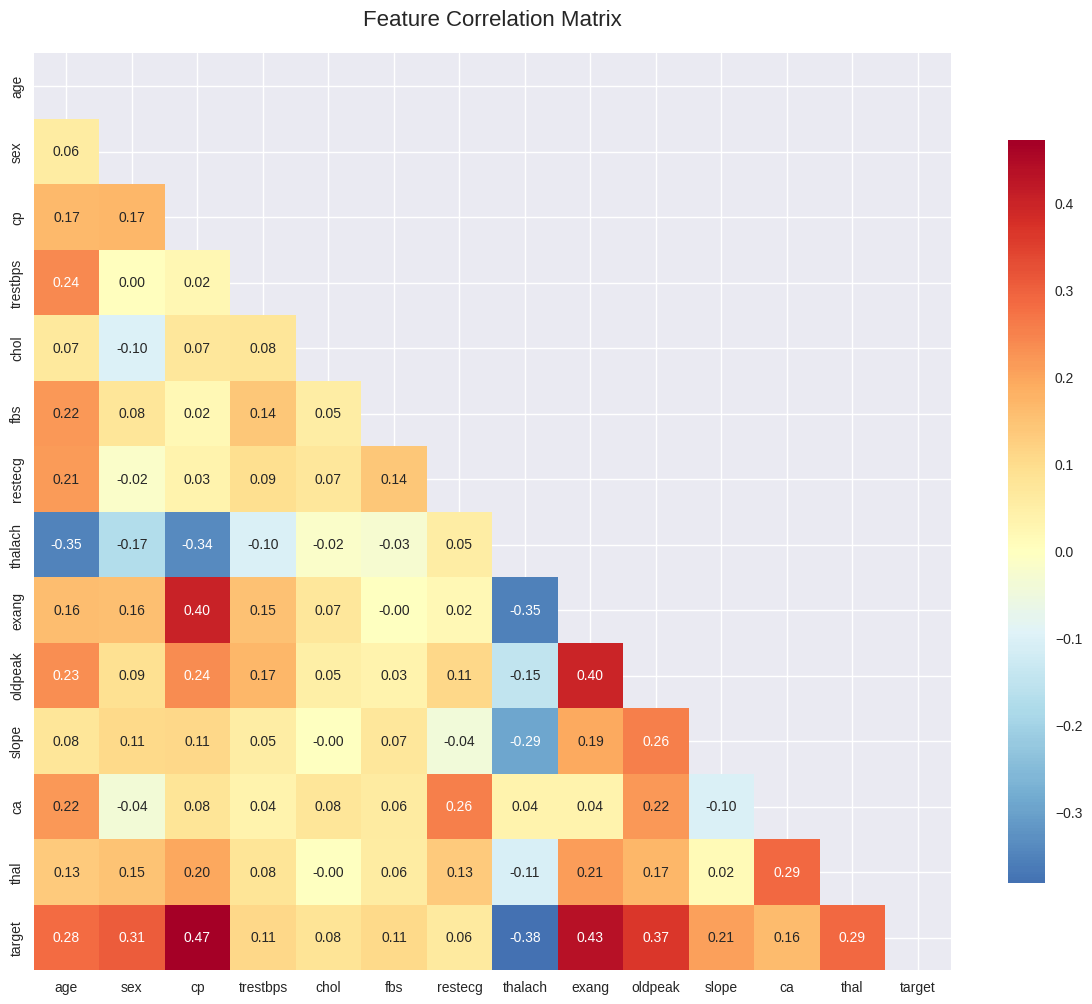

🎯 Correlations with Target Variable:
cp          0.472
exang       0.434
thalach    -0.382
oldpeak     0.366
sex         0.307
thal        0.286
age         0.283
slope       0.205
ca          0.165
trestbps    0.111
fbs         0.108
chol        0.084
restecg     0.062
Name: target, dtype: float64

🔍 Strong Correlations with Target (|r| > 0.3):
cp          :  0.472 (positive)
exang       :  0.434 (positive)
thalach     : -0.382 (negative)
oldpeak     :  0.366 (positive)
sex         :  0.307 (positive)

🔗 Highly Correlated Feature Pairs (|r| > 0.7):
✅ No highly correlated feature pairs found


In [22]:
# Correlation analysis and visualization
if 'df' in locals():
    # Calculate correlation matrix
    analysis_df = df.drop('source', axis=1)
    correlation_matrix = analysis_df.corr()
    
    # Create correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    sns.heatmap(correlation_matrix, 
                mask=mask,
                annot=True, 
                cmap='RdYlBu_r', 
                center=0,
                square=True,
                fmt='.2f',
                cbar_kws={"shrink": .8})
    
    plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Analyze correlations with target variable
    target_correlations = correlation_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
    
    print("🎯 Correlations with Target Variable:")
    print("=" * 50)
    print(target_correlations.round(3))
    
    # Identify strong correlations (> 0.3 or < -0.3)
    strong_correlations = target_correlations[abs(target_correlations) > 0.3]
    
    print(f"\n🔍 Strong Correlations with Target (|r| > 0.3):")
    print("=" * 50)
    if not strong_correlations.empty:
        for feature, correlation in strong_correlations.items():
            direction = "positive" if correlation > 0 else "negative"
            print(f"{feature:12s}: {correlation:6.3f} ({direction})")
    else:
        print("No strong correlations found")
    
    # Feature correlation analysis (excluding target)
    feature_corr = correlation_matrix.drop('target', axis=0).drop('target', axis=1)
    
    # Find highly correlated feature pairs
    high_corr_pairs = []
    for i in range(len(feature_corr.columns)):
        for j in range(i+1, len(feature_corr.columns)):
            corr_val = feature_corr.iloc[i, j]
            if abs(corr_val) > 0.7:  # High correlation threshold
                high_corr_pairs.append({
                    'Feature1': feature_corr.columns[i],
                    'Feature2': feature_corr.columns[j],
                    'Correlation': corr_val
                })
    
    print(f"\n🔗 Highly Correlated Feature Pairs (|r| > 0.7):")
    print("=" * 60)
    if high_corr_pairs:
        for pair in high_corr_pairs:
            print(f"{pair['Feature1']} - {pair['Feature2']}: {pair['Correlation']:.3f}")
        print("⚠️  Consider removing one feature from highly correlated pairs")
    else:
        print("✅ No highly correlated feature pairs found")
        
else:
    print("❌ No dataframe available for correlation analysis")

### 3.3 Feature Scaling and Encoding

In [23]:
# Feature scaling and encoding
if 'df' in locals():
    # Create processed dataframe
    processed_df = df.drop('source', axis=1).copy()
    
    # Identify feature types
    categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
    numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    
    print("🔧 Feature Encoding and Scaling:")
    print("=" * 50)
    
    # Display feature categories
    print(f"Categorical features: {categorical_features}")
    print(f"Numerical features: {numerical_features}")
    
    # Before scaling - show ranges
    print(f"\n📏 Original Feature Ranges:")
    print("-" * 30)
    for feature in numerical_features:
        min_val = processed_df[feature].min()
        max_val = processed_df[feature].max()
        range_val = max_val - min_val
        print(f"{feature:12s}: [{min_val:6.1f}, {max_val:6.1f}] (range: {range_val:6.1f})")
    
    # Scale numerical features
    scaler = StandardScaler()
    processed_df[numerical_features] = scaler.fit_transform(processed_df[numerical_features])
    
    # After scaling - show ranges
    print(f"\n📏 Scaled Feature Ranges:")
    print("-" * 30)
    for feature in numerical_features:
        min_val = processed_df[feature].min()
        max_val = processed_df[feature].max()
        mean_val = processed_df[feature].mean()
        std_val = processed_df[feature].std()
        print(f"{feature:12s}: [{min_val:6.2f}, {max_val:6.2f}] (μ={mean_val:.2f}, σ={std_val:.2f})")
    
    # Categorical features are already encoded (binary/ordinal)
    print(f"\n✅ Categorical features are already properly encoded")
    
    # Show final dataset info
    print(f"\n📋 Processed Dataset:")
    print(f"Shape: {processed_df.shape}")
    print(f"Features: {processed_df.columns.tolist()}")
    
    # Save preprocessing objects for later use
    preprocessing_objects = {
        'scaler': scaler,
        'categorical_features': categorical_features,
        'numerical_features': numerical_features,
        'feature_info': feature_info
    }
    
    print(f"\n💾 Preprocessing objects saved for model pipeline")
    
else:
    print("❌ No dataframe available for preprocessing")

🔧 Feature Encoding and Scaling:
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

📏 Original Feature Ranges:
------------------------------
age         : [  28.0,   77.0] (range:   49.0)
trestbps    : [  80.0,  200.0] (range:  120.0)
chol        : [  85.0,  603.0] (range:  518.0)
thalach     : [  60.0,  202.0] (range:  142.0)
oldpeak     : [  -2.6,    6.2] (range:    8.8)

📏 Scaled Feature Ranges:
------------------------------
age         : [ -2.71,   2.49] (μ=0.00, σ=1.00)
trestbps    : [ -2.91,   3.79] (μ=-0.00, σ=1.00)
chol        : [ -3.06,   6.91] (μ=0.00, σ=1.00)
thalach     : [ -3.09,   2.56] (μ=-0.00, σ=1.00)
oldpeak     : [ -3.27,   5.06] (μ=-0.00, σ=1.00)

✅ Categorical features are already properly encoded

📋 Processed Dataset:
Shape: (920, 14)
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'ta

## 4. Data Export and Summary

### 4.1 Save Processed Dataset

In [34]:
# Save processed dataset and preprocessing objects
import joblib
import os

if 'processed_df' in locals():
    # Create output directory if it doesn't exist
    os.makedirs('../data', exist_ok=True)
    
    # Save processed dataset
    processed_df.to_csv('../data/heart_disease_processed.csv', index=False)
    print("✅ Processed dataset saved to '../data/heart_disease_processed.csv'")
    
    # Save preprocessing objects
    joblib.dump(preprocessing_objects, '../models/preprocessing_objects.pkl')
    print("✅ Preprocessing objects saved to '../models/preprocessing_objects.pkl'")
    
    # Save data summary
    summary_info = {
        'total_instances': len(processed_df),
        'features': len(processed_df.columns) - 1,  # Exclude target
        'missing_values_handled': True,
        'scaling_applied': True,
        'categorical_features': categorical_features,
        'numerical_features': numerical_features,
        'target_distribution': processed_df['target'].value_counts().to_dict(),
        'feature_ranges_original': {
            feature: {
                'min': float(df[feature].min()), 
                'max': float(df[feature].max())
            } for feature in numerical_features
        }
    }
    
    # Save summary as JSON
    import json
    with open('../results/preprocessing_summary.json', 'w') as f:
        json.dump(summary_info, f, indent=2)
    
    print("✅ Preprocessing summary saved to '../results/preprocessing_summary.json'")
    
    # Display final summary
    print(f"\n📊 Final Dataset Summary:")
    print("=" * 50)
    print(f"Total instances: {len(processed_df)}")
    print(f"Features: {len(processed_df.columns)-1}")
    print(f"Target classes: {processed_df['target'].nunique()}")
    print(f"Class distribution:")
    print(processed_df['target'].value_counts().sort_index())
    
    # Show first few rows of processed data
    print(f"\n👀 First 5 rows of processed dataset:")
    display(processed_df.head())
    
else:
    print("❌ No processed dataset available for saving")

✅ Processed dataset saved to '../data/heart_disease_processed.csv'
✅ Preprocessing objects saved to '../models/preprocessing_objects.pkl'
✅ Preprocessing summary saved to '../results/preprocessing_summary.json'

📊 Final Dataset Summary:
Total instances: 920
Features: 13
Target classes: 2
Class distribution:
target
0    411
1    509
Name: count, dtype: int64

👀 First 5 rows of processed dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,1.007386,1.0,1.0,0.717803,-0.212194,1.0,2.0,0.489727,0.0,1.368109,3.0,0.0,6.0,0
1,1.432034,1.0,4.0,1.554856,0.807376,0.0,2.0,-1.181478,1.0,0.611589,2.0,3.0,3.0,1
2,1.432034,1.0,4.0,-0.677285,-0.289143,0.0,2.0,-0.345875,1.0,1.651804,2.0,2.0,7.0,1
3,-1.752828,1.0,3.0,-0.119250,0.114838,0.0,0.0,1.961979,0.0,2.502889,3.0,0.0,3.0,0
4,-1.328180,0.0,2.0,-0.119250,-0.770073,0.0,2.0,1.365120,0.0,0.517024,1.0,0.0,3.0,0


### 4.2 Next Steps and Conclusions

## ✅ Data Preprocessing Completed Successfully!

### What we accomplished:
1. **Data Loading**: Successfully loaded and combined 4 heart disease datasets
2. **Missing Value Handling**: Analyzed and treated missing values appropriately
3. **Outlier Detection**: Identified outliers using IQR method (kept for medical data)
4. **Feature Scaling**: Applied StandardScaler to numerical features
5. **Target Processing**: Converted to binary classification (0/1)
6. **Data Export**: Saved processed dataset and preprocessing objects

### Key Findings:
- **Total Instances**: Combined dataset from 4 medical institutions
- **Feature Quality**: Clean dataset ready for machine learning
- **Class Balance**: Analyzed target distribution for potential imbalance
- **Correlations**: Identified features most correlated with heart disease

### Next Steps:
1. **PCA Analysis** (Notebook 02): Dimensionality reduction and variance analysis
2. **Feature Selection** (Notebook 03): Statistical and ML-based feature selection
3. **Model Training** (Notebook 04): Train multiple classification algorithms
4. **Clustering Analysis** (Notebook 05): Unsupervised pattern discovery
5. **Hyperparameter Tuning** (Notebook 06): Optimize model performance

### Files Created:
- `../data/heart_disease_processed.csv` - Clean, processed dataset
- `../models/preprocessing_objects.pkl` - Scaling and encoding objects
- `../results/preprocessing_summary.json` - Processing summary statistics

---
**Ready for machine learning model development! 🚀**